# Cuaderno 4: Muestreo y cuantización

Este cuaderno se concentra en dos preguntas importantes:

- ¿qué pasa cuando una imagen tiene menos muestras espaciales?
- ¿qué pasa cuando una imagen tiene menos niveles de intensidad?

Responder esas preguntas ayuda a entender cómo una imagen digital pierde o conserva información.

## Objetivos

- Analizar una imagen como matriz de intensidades.
- Reducir la resolución espacial por muestreo.
- Implementar un histograma manual simple.
- Reducir niveles de gris por cuantización.
- Comparar visualmente y numéricamente los resultados.


In [6]:
# Importa librerias para analizar imagenes y define funciones auxiliares:
# una para describir propiedades basicas de la imagen y otra para calcular
# manualmente el histograma contando cuantos pixeles hay en cada nivel de gris.

import matplotlib.pyplot as plt
import numpy as np
import skimage as ski


def analizar_imagen(imagen, nombre="Imagen"):
    print(nombre)
    print(f"  forma: {imagen.shape}")
    print(f"  tipo de dato: {imagen.dtype}")
    print(f"  mínimo: {imagen.min()}")
    print(f"  máximo: {imagen.max()}")
    print(f"  rango dinámico: {imagen.max() - imagen.min()}")


def calcular_histograma_manual(imagen, n_bins=256):
    hist = np.zeros(n_bins, dtype=int)
    filas, columnas = imagen.shape

    for i in range(filas):
        for j in range(columnas):
            hist[imagen[i, j]] += 1

    return hist


Imagen original
  forma: (512, 512)
  tipo de dato: uint8
  mínimo: 0
  máximo: 255
  rango dinámico: 255


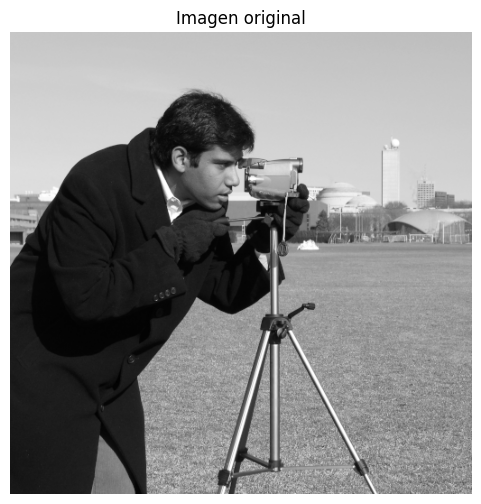

In [7]:
# Carga una imagen de ejemplo en escala de grises, muestra sus propiedades
# basicas y la visualiza usando el rango completo de intensidades de 0 a 255.


imagen = ski.data.camera()

analizar_imagen(imagen, "Imagen original")

plt.figure(figsize=(6, 6))
plt.imshow(imagen, cmap="gray", vmin=0, vmax=255)
plt.title("Imagen original")
plt.axis("off")
plt.show()


## 1. Muestreo espacial

El muestreo espacial indica cuántos píxeles usamos para representar la imagen. Si tomamos menos muestras, la imagen conserva la estructura general, pero pierde detalle fino.


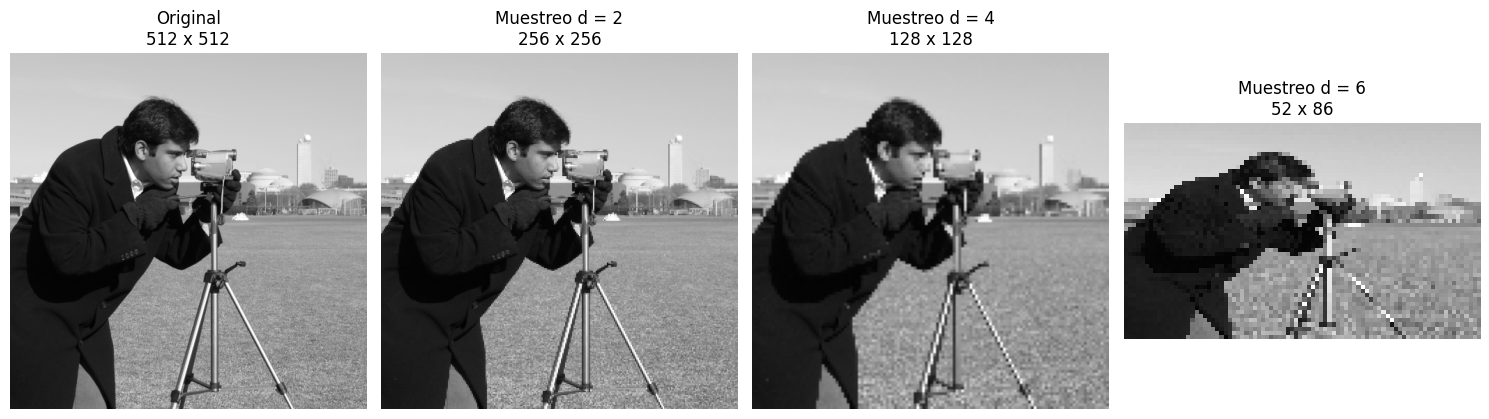

In [9]:
# Aplico muestreo espacial tomando un pixel cada 2 y cada 4 posiciones.
# Esto reduce la resolucion de la imagen y permite ver como se pierde detalle
# cuando disminuye la cantidad de muestras.


paso_2 = imagen[::2, ::2]
paso_4 = imagen[::4, ::4]
paso_6 = imagen[::10, ::6]

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title(f"Original\n{imagen.shape[0]} x {imagen.shape[1]}")
axes[0].axis("off")

axes[1].imshow(paso_2, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Muestreo d = 2\n{paso_2.shape[0]} x {paso_2.shape[1]}")
axes[1].axis("off")

axes[2].imshow(paso_4, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Muestreo d = 4\n{paso_4.shape[0]} x {paso_4.shape[1]}")
axes[2].axis("off")

axes[3].imshow(paso_6, cmap="gray", vmin=0, vmax=255)
axes[3].set_title(f"Muestreo d = 6\n{paso_6.shape[0]} x {paso_6.shape[1]}")
axes[3].axis("off")

plt.tight_layout()
plt.show()


## Pregunta guía

Observá las tres imágenes y pensá:

- ¿qué detalles desaparecen primero?
Los primeros detalles que desaparecen son los de alta frecuencia espacial: texturas finas, bordes delgados y pequeños cambios de intensidad. En esta imagen, eso se nota antes en el pasto, algunos rasgos de la cara, partes del trípode y contornos pequeños de la cámara.
- ¿la pérdida de información afecta del mismo modo a toda la imagen?
La pérdida de información no afecta igual a toda la imagen. Las zonas más uniformes, como el cielo o superficies lisas, resisten mejor el muestreo porque cambian poco entre píxeles. En cambio, las regiones con mucho detalle o contraste se degradan rápido y se ven borrosas o pixeladas.
- ¿en qué situaciones convendría aceptar esa pérdida?
cuando el objetivo no necesita tanto detalle: por ejemplo, para vista previa, transmisión más liviana, almacenamiento con menos tamaño, procesamiento más rápido o tareas donde importa la forma general y no los detalles finos. Si hay que medir, diagnosticar o analizar texturas pequeñas, esa pérdida ya no conviene.


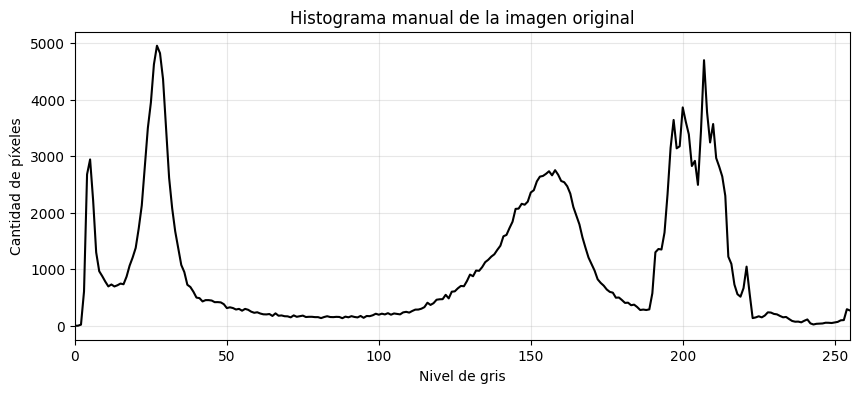

In [10]:
# Calcula y grafica el histograma de la imagen original para visualizar la distribución 
# de niveles de gris.

hist_original = calcular_histograma_manual(imagen)
#calcular_histograma_manual(imagen) cuenta cuántos píxeles hay en cada nivel de gris, 
#desde 0 hasta 255. Después, matplotlib dibuja esa distribución como una curva, 
#para ver cómo están repartidas las intensidades de la imagen: si predominan tonos 
#oscuros, claros o medios, y si hay mucho o poco contraste.

plt.figure(figsize=(10, 4))
plt.plot(hist_original, color="black", linewidth=1.5)
plt.title("Histograma manual de la imagen original")
plt.xlabel("Nivel de gris")
plt.ylabel("Cantidad de píxeles")
plt.grid(alpha=0.3)
plt.xlim(0, 255)
plt.show()
# El histograma permite analizar cómo se distribuyen los niveles de gris de la imagen,
# mostrando si predominan tonos oscuros, claros y el grado de contraste presente.
#En resumen, del histograma podés extraer brillo, contraste y distribución tonal de la imagen, 
#aunque no te dice dónde están esos píxeles dentro de la imagen.


## 2. Cuantización

La cuantización reduce la cantidad de niveles de gris disponibles. La imagen conserva su forma general, pero los cambios suaves de intensidad se vuelven más bruscos.
La cuantización tiene como objetivo reducir la cantidad de niveles de intensidad que puede tomar una imagen.

En vez de trabajar, por ejemplo, con 256 niveles de gris, se la puede representar con menos niveles, como 128, 64, 16 o 8. Eso hace que varios valores parecidos se agrupen en uno mismo.

¿Para qué sirve?

Reduce la cantidad de información que hay que almacenar.
Simplifica el procesamiento de la imagen.
Puede acelerar ciertos algoritmos.
Es útil en compresión y en sistemas con recursos limitados.
Permite analizar cómo afecta la pérdida de precisión visual.

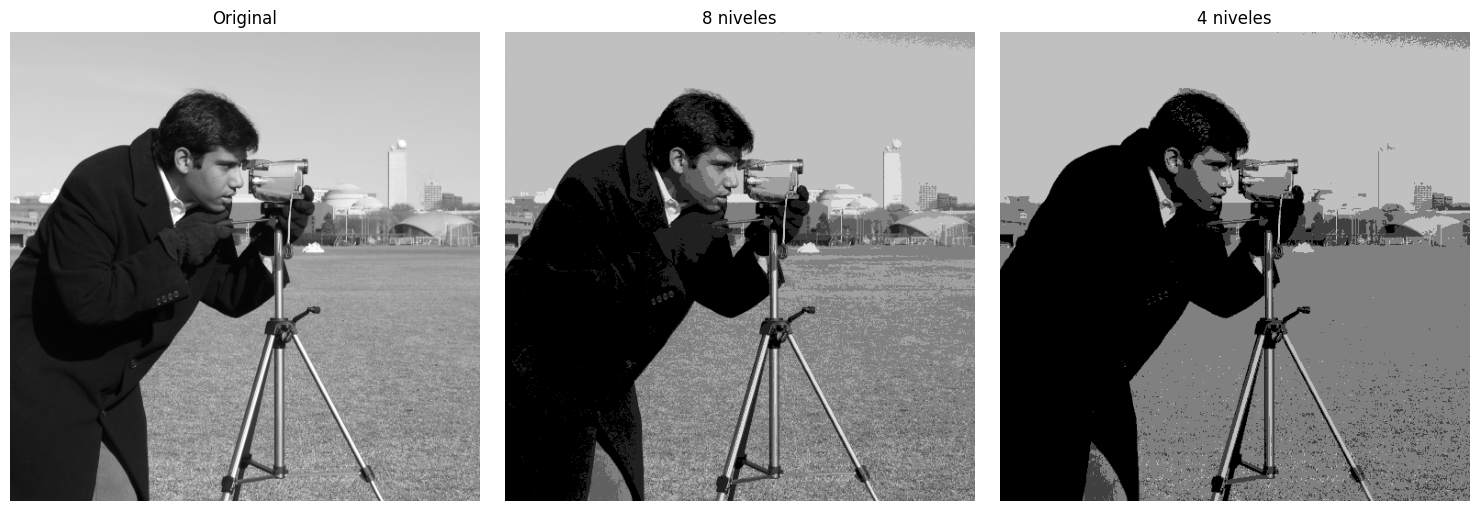

In [ ]:
# Cuantiza la imagen a distintos niveles de gris y compara el resultado con la imagen original.

def cuantizar(imagen, niveles):
    paso = 256 // niveles
    return (imagen // paso) * paso
#Calcula el tamaño de cada intervalo de niveles con paso = 256 // niveles.
#Divide cada píxel por ese paso para agruparlo.
#Multiplica de nuevo por paso para que todos los valores del grupo queden en un mismo nivel.


cuant_8 = cuantizar(imagen, 8)
cuant_4 = cuantizar(imagen, 4)
#generan dos versiones nuevas:
# una con 8 niveles de gris
# otra con 4 niveles de gris

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
#se crean tres gráficos en una fila para mostrar:
# la imagen original
# la imagen cuantizada a 8 niveles
# la imagen cuantizada a 4 niveles
#Esto permite observar que, al bajar los niveles de gris:
# se pierde suavidad entre tonos
# aparecen saltos más bruscos entre intensidades
# la imagen se ve más simplificada o “escalonada”

axes[0].imshow(imagen, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cuant_8, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("8 niveles")
axes[1].axis("off")

axes[2].imshow(cuant_4, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("4 niveles")
axes[2].axis("off")

plt.tight_layout()
plt.show()


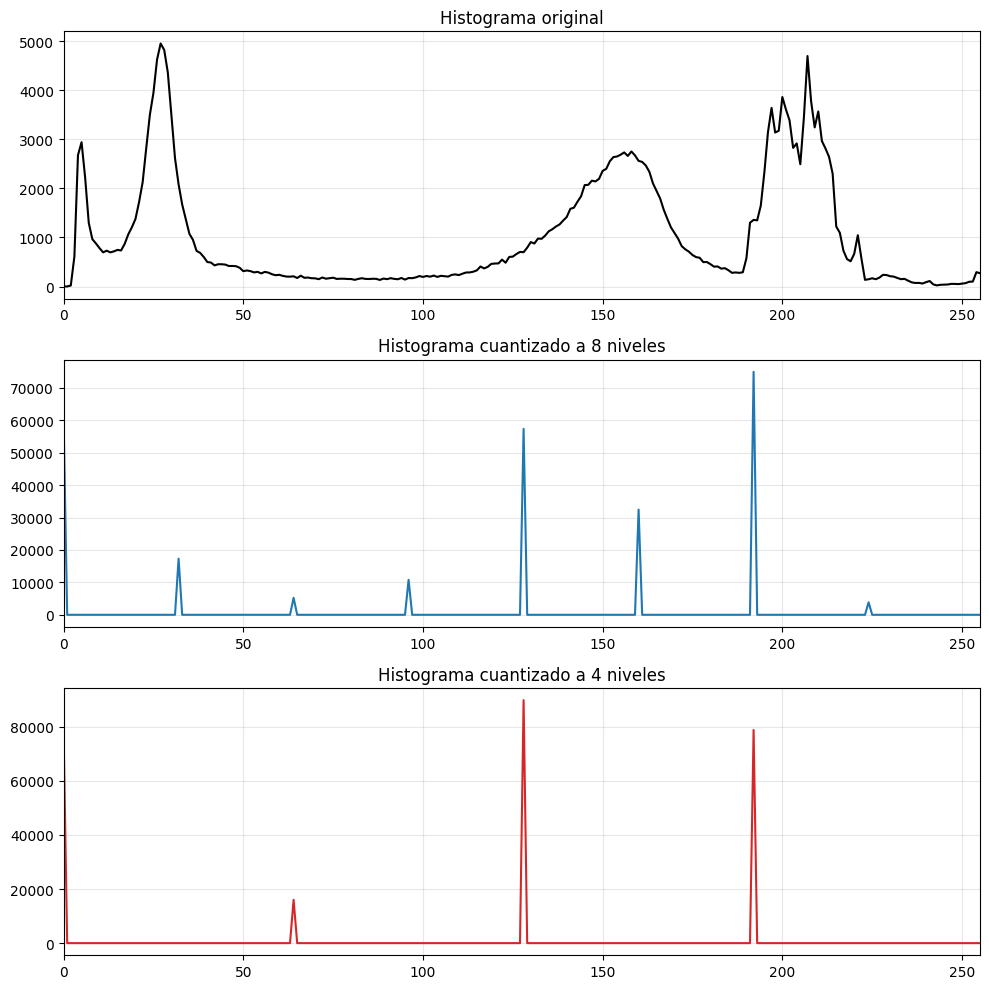

In [12]:
## Calcula y compara los histogramas de la imagen original y sus versiones cuantizadas para observar cómo se reducen los niveles de gris.

hist_cuant_8 = calcular_histograma_manual(cuant_8)
hist_cuant_4 = calcular_histograma_manual(cuant_4)

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

#En la imagen original, el histograma suele tener muchos valores distribuidos en varios niveles.
axes[0].plot(hist_original, color="black")#histograma original
axes[0].set_title("Histograma original")
#estas dos lineas todos los gráficos usen el mismo rango de niveles de gris y 
# agregan una grilla suave para leerlos mejor.
axes[0].set_xlim(0, 255)
axes[0].grid(alpha=0.3)

#En la cuantizada a 8 niveles, los valores se concentran en menos intensidades.
axes[1].plot(hist_cuant_8, color="tab:blue")#histograma de la imagen cuantizada a 8 niveles
axes[1].set_title("Histograma cuantizado a 8 niveles")
axes[1].set_xlim(0, 255)
axes[1].grid(alpha=0.3)

#En la cuantizada a 4 niveles, todavía más: aparecen menos picos, pero más marcados.
axes[2].plot(hist_cuant_4, color="tab:red")#histograma de la imagen cuantizada a 4 niveles
axes[2].set_title("Histograma cuantizado a 4 niveles")
axes[2].set_xlim(0, 255)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Cierre

Muestrear y cuantizar no significan lo mismo:

- el muestreo modifica la cantidad de información espacial;
- la cuantización modifica la cantidad de niveles posibles.

En ambos casos hay pérdida de información, pero esa pérdida no afecta del mismo modo a la imagen. Entender esa diferencia es clave para leer, comprimir, segmentar y analizar imágenes digitales.


En este trabajo se observó cómo el muestreo y la cuantización afectan la calidad y la información de una imagen digital. El muestreo reduce la cantidad de píxeles, por lo que se pierde detalle espacial y la imagen se ve más pixelada. La cuantización, en cambio, reduce la cantidad de niveles de gris disponibles, lo que simplifica los tonos y genera transiciones más bruscas entre intensidades. En ambos casos, la imagen conserva su contenido general, pero pierde precisión visual. Esto permite entender que toda imagen digital es una aproximación de la realidad y que existe un compromiso entre calidad, almacenamiento y costo de procesamiento.